# U.S. Gross Domestic Product and Employee Wage Growth (2024 – Present)

## Analysis Specification

### Description
This analytical tracking framework explores the interplay between U.S. macroeconomic growth and employee earnings data from 2024 to the present. By combining broad output indexes—such as Real GDP, Potential GDP, and GDP per capita—with dynamic hourly and weekly wage metrics across different demographic groups, this document serves to map out whether current productivity gains are filtering equitably into workers' real earnings. The project relies strictly on continuous, high-frequency time-series datasets provided by the Federal Reserve Economic Data (FRED) system.

---

## Objectives

*   **Evaluate Growth vs. Potential Outputs:** Monitor the official trajectory of economic output using Real GDP (`GDPC1`) mapped against Potential GDP (`GDPPOT`) to ascertain the output gap and identify periods of economic overheating or cooling.
*   **Deconstruct Employee Wage Trajectories:** Analyze differences in nominal, weekly, and hourly earnings metrics across distinct employee demographics to determine if high-skilled labor segments (`LEU0252918500Q`) outpace or lag behind general private workforce averages (`CES0500000011`, `LES1252881500Q`).
*   **Measure Disposable Income Health:** Cross-examine real gross productivity spikes per capita (`A939RX0Q048SBEA`) with the actual movement of Real Disposable Personal Income (`DSPIC96`) to gauge the average individual’s true purchasing power in an inflationary climate.
*   **Establish Automated Pipelines:** Provide a standardized, reproducible technical baseline using structural components like Python frameworks (`pandas-datareader`) to live-fetch and continuously refresh these specific macroeconomic indexes for long-term tracking.

---

## Data Source

- **Federal Reserve Economic Data (FRED)**  
  - `GDPC1`: Real Gross Domestic Product
  - `GDPPOT`: Real Potential Gross Domestic Product
  - `DSPIC96`: Real Disposable Personal Income
  - `A939RX0Q048SBEA` : Real Gross Domestic Product Per Capita
  - `LES1252881500Q`: Employed full time: Median usual weekly nominal earnings (second quartile): Wage and salary workers: 16 years and over
  - `LEU0252918500Q`: Employed full time: Median usual weekly nominal earnings (second quartile): Wage and salary workers: Bachelor's degree and higher: 25 years and over
  - `CES0500000011`: Average Weekly Earnings of All Employees, Total Private 

---



In [4]:
# Install system dependencies
!pip install pandas-datareader

## Earnings for U.S. Employees

### Weekly Earnings (2024 - Present)

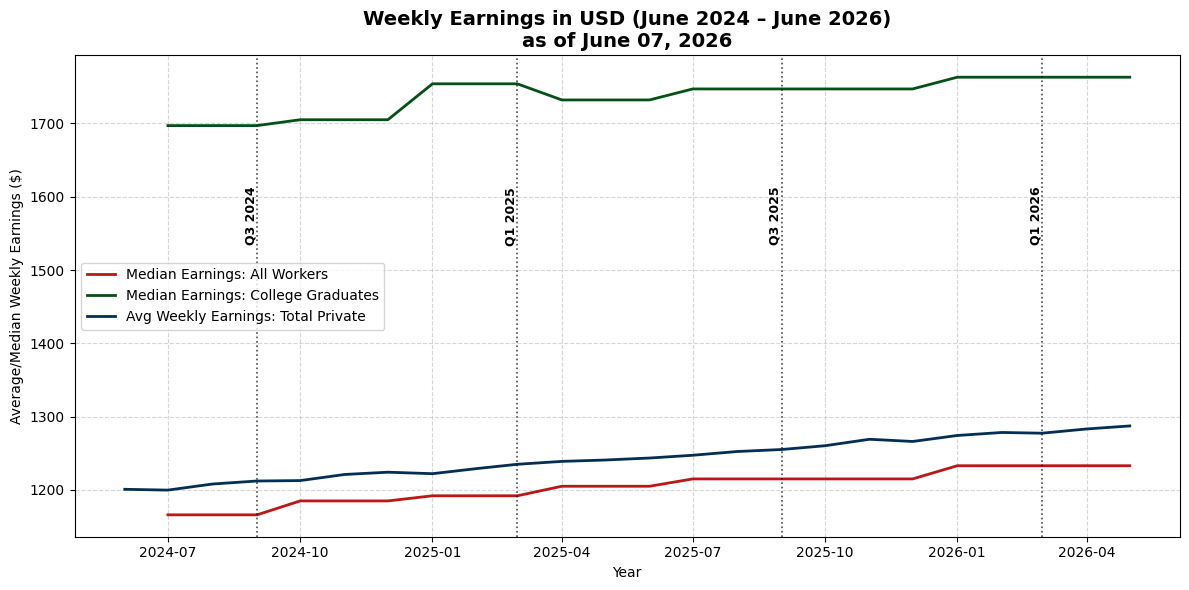

In [7]:
# Imports
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
from datetime import datetime
from dateutil.relativedelta import relativedelta

start = datetime(2024, 6, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

earn_series = {
    'LES1252881500Q': 'Median Earnings: All Workers',
    'LEU0252918500Q': 'Median Earnings: College Graduates',
    'CES0500000011': 'Avg Weekly Earnings: Total Private'
}

df_raw = web.DataReader(list(earn_series.keys()), 'fred', start, end)
df_raw.rename(columns=earn_series, inplace=True)
df_raw = df_raw.ffill()

df_plot = df_raw.loc[start:end]

plt.figure(figsize=(12, 6))

plt.plot(df_plot.index, df_plot['Median Earnings: All Workers'], 
         label='Median Earnings: All Workers', 
         color="#bd1616", 
         linewidth=2)

plt.plot(df_plot.index, df_plot['Median Earnings: College Graduates'], 
         label='Median Earnings: College Graduates', 
         color="#035117", 
         linewidth=2)

plt.plot(df_plot.index, df_plot['Avg Weekly Earnings: Total Private'], 
         label='Avg Weekly Earnings: Total Private', 
         color="#042E53", 
         linewidth=2)

y = plt.ylim()[1] * 0.9

events = {
    '2024-09-01': 'Q3 2024',
    '2025-03-01': 'Q1 2025',
    '2025-09-01': 'Q3 2025',
    '2026-03-01': 'Q1 2026'
}

for date_str, label in events.items():
    evt_date = pd.to_datetime(date_str)
    if df_plot.index.min() <= evt_date <= df_plot.index.max():
        plt.axvline(x=evt_date, 
                    color='black', 
                    linestyle=':', 
                    linewidth=1.2, 
                    alpha=0.7)
        plt.text(evt_date, y, label,
                 rotation=90, 
                 verticalalignment='top',
                 horizontalalignment='right',
                 fontsize=9,
                 fontweight='bold')

plt.title(f'Weekly Earnings in USD ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', 
          fontsize=14, 
          fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average/Median Weekly Earnings ($)')  # Updated label
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='center left')
plt.tight_layout()

plt.show()

### Earnings Growth Year-over-Year (2024 - Present)

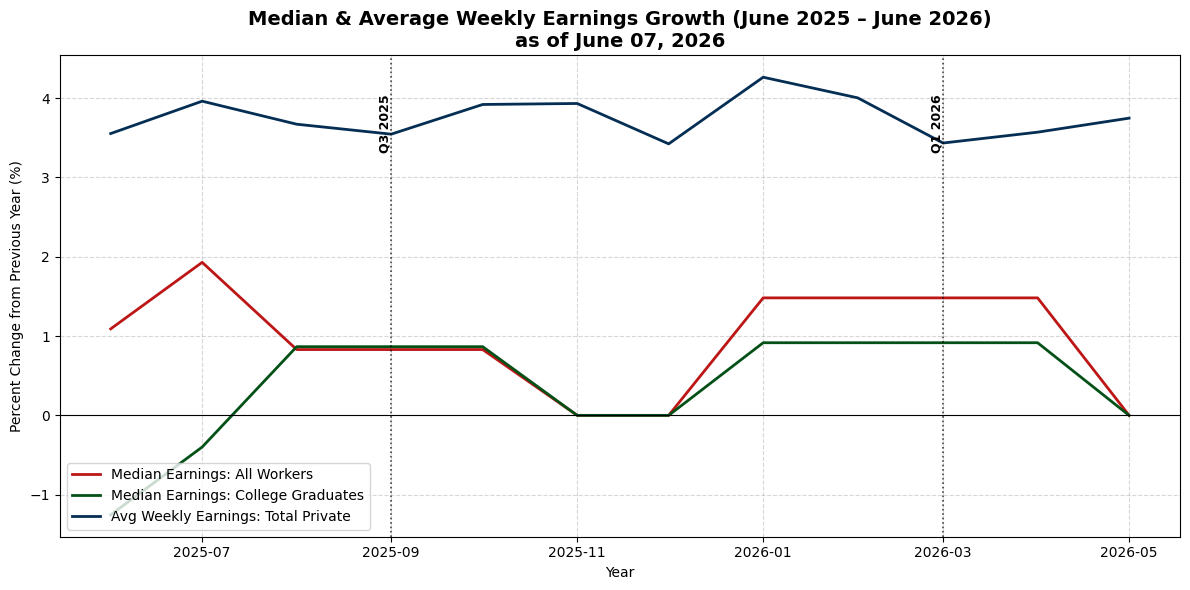

In [ ]:
df_rate = pd.DataFrame(index=df_raw.index)
df_rate['All Workers (YoY %Change)'] = df_raw['Median Earnings: All Workers'].pct_change(4) * 100
df_rate['College Graduates (YoY %Change)'] = df_raw['Median Earnings: College Graduates'].pct_change(4) * 100
df_rate['Total Private Employees (YoY %Change)'] = df_raw['Avg Weekly Earnings: Total Private'].pct_change(12) * 100

df_plot = df_rate.loc[plot_start:end]

plt.figure(figsize=(12, 6))

plt.plot(df_plot.index, df_plot['All Workers (YoY %Change)'], 
         label='Median Earnings: All Workers', 
         color="#bd1616", 
         linewidth=2)

plt.plot(df_plot.index, df_plot['College Graduates (YoY %Change)'], 
         label='Median Earnings: College Graduates', 
         color="#035117", 
         linewidth=2)

plt.plot(df_plot.index, df_plot['Total Private Employees (YoY %Change)'], 
         label='Avg Weekly Earnings: Total Private', 
         color="#042E53", 
         linewidth=2)

y = df_plot.max().max() * 0.95

for date_str, label in events.items():
    evt_date = pd.to_datetime(date_str)
    if df_plot.index.min() <= evt_date <= df_plot.index.max():
        plt.axvline(x=evt_date, 
                    color='black', 
                    linestyle=':', 
                    linewidth=1.2, 
                    alpha=0.7)
        plt.text(evt_date, y, label,
                 rotation=90, 
                 verticalalignment='top',
                 horizontalalignment='right',
                 fontsize=9,
                 fontweight='bold')

plt.title(f'Median & Average Weekly Earnings Growth ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', 
          fontsize=14, 
          fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percent Change from Previous Year (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()

plt.show()

## Gross Domestic Product (GDP) in the U.S. (January 2024-Present)
### Real GDP, Gross Potential GDP, Real Disposable Income

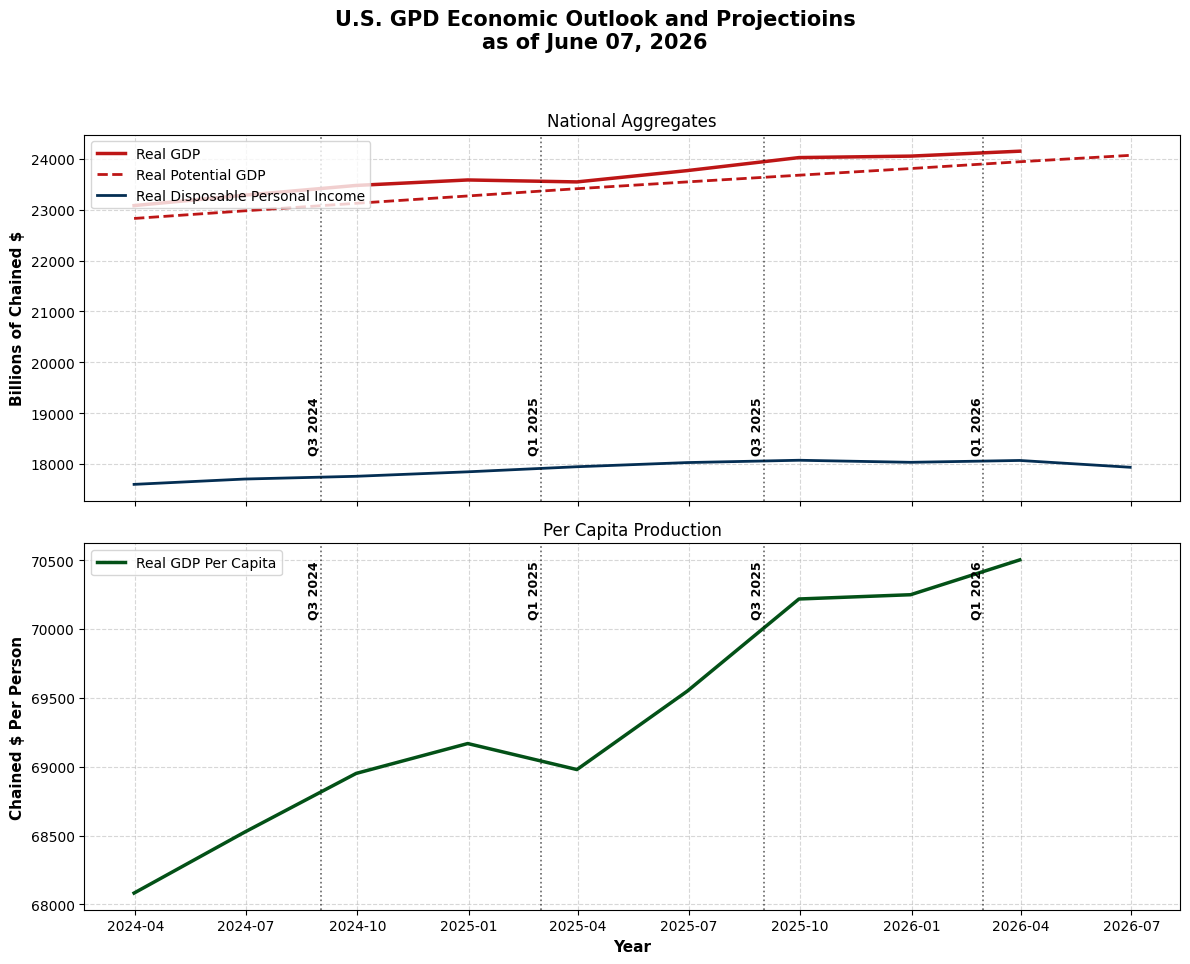

In [30]:
start = datetime(2024, 1, 1)

macro_series = {
    'GDPC1': 'Real GDP',
    'GDPPOT': 'Real Potential GDP',
    'DSPIC96': 'Real Disposable Personal Income',
    'A939RX0Q048SBEA': 'Real GDP Per Capita'
}

df_raw = web.DataReader(list(macro_series.keys()), 'fred', start, end)
df_raw.rename(columns=macro_series, inplace=True)

df_plot = df_raw.resample('QE').mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(df_plot.index, df_plot['Real GDP'], 
         label='Real GDP', 
         color='#bd1616', 
         linewidth=2.5)

ax1.plot(df_plot.index, df_plot['Real Potential GDP'], 
         label='Real Potential GDP', 
         color='#bd1616', 
         linewidth=2, 
         linestyle='--')

ax1.plot(df_plot.index, df_plot['Real Disposable Personal Income'], 
         label='Real Disposable Personal Income', 
         color='#042E53', 
         linewidth=2)
        
ax1.set_ylabel('Billions of Chained $', fontweight='bold', fontsize=11)
ax1.title.set_text('National Aggregates')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', frameon=True)

ax2.plot(df_plot.index, df_plot['Real GDP Per Capita'], 
         label='Real GDP Per Capita', color='#035117', linewidth=2.5)

ax2.set_xlabel('Year', fontweight='bold', fontsize=11)
ax2.set_ylabel('Chained $ Per Person', fontweight='bold', fontsize=11)
ax2.title.set_text('Per Capita Production')
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.legend(loc='upper left', frameon=True)

y1_text = df_plot[['Real GDP', 'Real Potential GDP', 'Real Disposable Personal Income']].max().max() * 0.8
y2_text = df_plot['Real GDP Per Capita'].max() 

for date_str, label in events.items():
    evt_date = pd.to_datetime(date_str)
    
    if df_plot.index.min() <= evt_date <= df_plot.index.max():
        
        # Draw on Top Subplot (ax1)
        ax1.axvline(x=evt_date, color='black', linestyle=':', linewidth=1.2, alpha=0.6)
        ax1.text(evt_date, y1_text, label,
                 rotation=90, 
                 verticalalignment='top',
                 horizontalalignment='right',
                 fontsize=9,
                 fontweight='bold')
        
        ax2.axvline(x=evt_date, color='black', linestyle=':', linewidth=1.2, alpha=0.6)
        ax2.text(evt_date, y2_text, label,
                 rotation=90, 
                 verticalalignment='top',
                 horizontalalignment='right',
                 fontsize=9,
                 fontweight='bold')
        
plt.suptitle(f'U.S. GPD Economic Outlook and Projectioins\nas of {str_current_date}', 
             fontsize=15, fontweight='bold', y=0.96)

plt.tight_layout(rect=[0, 0, 1, 0.93]) 

plt.show()

### GDP, PGDP, DPI Growth (YoY %) (2016 - Present)

/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_73929/2980011880.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_rate['Real GDP'] = df_quarterly['Real GDP'].pct_change(4) * 100
/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_73929/2980011880.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_rate['Real GDP Per Capita'] = df_quarterly['Real GDP Per Capita'].pct_change(4) * 100


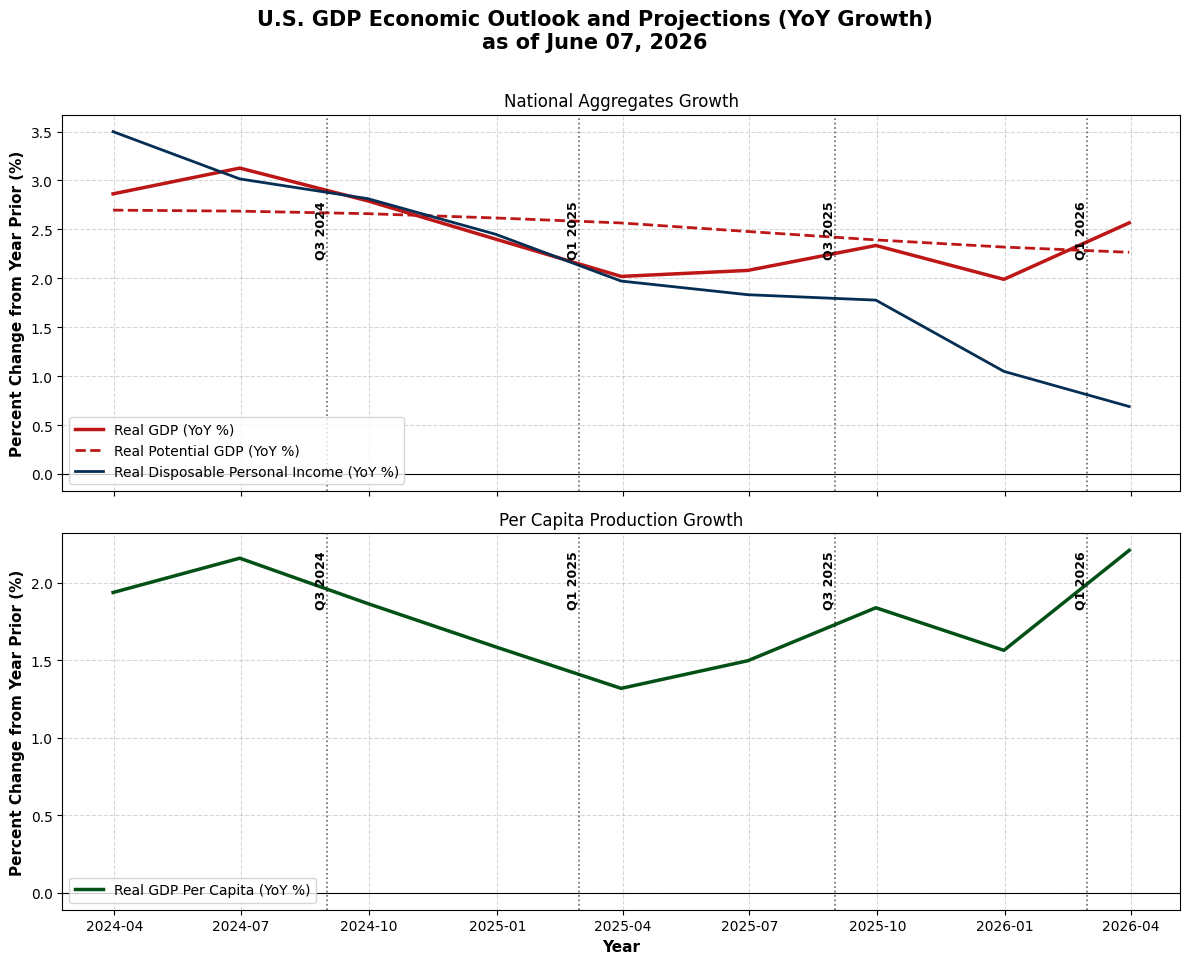

In [ ]:
macro_series = {
    'GDPC1': 'Real GDP',
    'GDPPOT': 'Real Potential GDP',
    'DSPIC96': 'Real Disposable Personal Income',
    'A939RX0Q048SBEA': 'Real GDP Per Capita'
}

df_raw = web.DataReader(list(macro_series.keys()), 'fred', start, end)
df_raw.rename(columns=macro_series, inplace=True)
df_quarterly = df_raw.resample('QE').mean()

df_rate = pd.DataFrame(index=df_quarterly.index)
df_rate['Real GDP'] = df_quarterly['Real GDP'].pct_change(4) * 100
df_rate['Real Potential GDP'] = df_quarterly['Real Potential GDP'].pct_change(4) * 100
df_rate['Real Disposable Personal Income'] = df_quarterly['Real Disposable Personal Income'].pct_change(4) * 100
df_rate['Real GDP Per Capita'] = df_quarterly['Real GDP Per Capita'].pct_change(4) * 100

df_plot = df_rate.loc[plot_start:end]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(df_plot.index, df_plot['Real GDP'], 
         label='Real GDP (YoY %)', 
         color='#bd1616', 
         linewidth=2.5)

ax1.plot(df_plot.index, df_plot['Real Potential GDP'], 
         label='Real Potential GDP (YoY %)', 
         color='#bd1616', 
         linewidth=2, 
         linestyle='--')

ax1.plot(df_plot.index, df_plot['Real Disposable Personal Income'], 
         label='Real Disposable Personal Income (YoY %)', 
         color='#042E53', 
         linewidth=2)
        
ax1.set_ylabel('Percent Change from Year Prior (%)', fontweight='bold', fontsize=11)
ax1.title.set_text('National Aggregates Growth')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax1.legend(loc='lower left', frameon=True)

ax2.plot(df_plot.index, df_plot['Real GDP Per Capita'], 
         label='Real GDP Per Capita (YoY %)', color='#035117', linewidth=2.5)

ax2.set_xlabel('Year', fontweight='bold', fontsize=11)
ax2.set_ylabel('Percent Change from Year Prior (%)', fontweight='bold', fontsize=11)
ax2.title.set_text('Per Capita Production Growth')
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax2.legend(loc='lower left', frameon=True)

y1_text = df_plot[['Real GDP', 'Real Potential GDP', 'Real Disposable Personal Income']].max().max() * 0.8
y2_text = df_plot['Real GDP Per Capita'].max() 

for date_str, label in events.items():
    evt_date = pd.to_datetime(date_str)
    
    if df_plot.index.min() <= evt_date <= df_plot.index.max():
        ax1.axvline(x=evt_date, color='black', linestyle=':', linewidth=1.2, alpha=0.6)
        ax1.text(evt_date, y1_text, label,
                 rotation=90, 
                 verticalalignment='top',
                 horizontalalignment='right',
                 fontsize=9,
                 fontweight='bold')
        
        ax2.axvline(x=evt_date, color='black', linestyle=':', linewidth=1.2, alpha=0.6)
        ax2.text(evt_date, y2_text, label,
                 rotation=90, 
                 verticalalignment='top',
                 horizontalalignment='right',
                 fontsize=9,
                 fontweight='bold')
        
plt.suptitle(f'U.S. GDP Economic Outlook and Projections (YoY Growth)\nas of {str_current_date}', 
             fontsize=15, fontweight='bold', y=0.96)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Consumer Price Index for All Urban Consumers (2022 - Present)

In [ ]:
start = datetime(2022, 1, 1)
df = web.DataReader('CPIAUCSL', 'fred', start, end)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['CPIAUCSL'], label="Percent Change from Previous Year", color="#d42c06", linewidth=2)

y = plt.ylim()[1]*0.5

# Event Markers
evt_24Q1 = pd.to_datetime('2024-01-1')
evt_25Q1 = pd.to_datetime('2025-01-1')
evt_26Q1 = pd.to_datetime('2026-01-1')

plt.axvline(x=evt_24Q1, color='black', linestyle='-', linewidth=1)
plt.axvline(x=evt_25Q1, color='black', linestyle='-', linewidth=1)
plt.axvline(x=evt_26Q1, color='black', linestyle='-', linewidth=1)

plt.text(evt_24Q1, y, '3.08834 - Q1 2024',
         rotation=90, 
         verticalalignment='bottom',
         horizontalalignment='right',
         fontsize=9)

plt.text(evt_25Q1, y, '2.9908 - Q1 2025',
         rotation=90, 
         verticalalignment='bottom',
         horizontalalignment='right',
         fontsize=9)

plt.text(evt_26Q1, y, '2.39120 - Q1 2026',
         rotation=90, 
         verticalalignment='bottom',
         horizontalalignment='right',
         fontsize=9)

plt.title(f'Urban CPI ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Chained 2017 Dollars')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
rate_series = {
    'PCETRIM12M159SFRBDAL': 'Trimmed Mean PCE Inflation Rate',
    'DPCCRV1A225NBEA': 'PCE Inflation Rate Excluding Food and Energy',
}

df_raw = web.DataReader(list(rate_series.keys()), 'fred', start, end)
df_raw.rename(columns=rate_series, inplace=True)

df_rate = pd.DataFrame()
df_rate['Trimmed Mean PCE Inflation Rate'] = df_raw['Trimmed Mean PCE Inflation Rate']
df_rate['PCE Rate Excluding Food and Energy'] = df_raw['PCE Inflation Rate Excluding Food and Energy'].pct_change(12) * 100

start = datetime(2022, 1, 1)

plt.figure(figsize=(12, 6))
plt.plot(df_rate.index, df_rate['Trimmed Mean PCE Inflation Rate'], label="Mean PCE Inflation", color="#d42c06", linewidth=2)
plt.plot(df_rate.index, df_rate['PCE Rate Excluding Food and Energy'], label="PCE Rate Excluding Food and Energy", color="#0640d4", linewidth=2)
y = plt.ylim()[1]*0.25

# Event Markers
evt_24Q1 = pd.to_datetime('2024-01-1')
evt_25Q1 = pd.to_datetime('2025-01-1')
evt_26Q1 = pd.to_datetime('2026-01-1')

plt.axvline(x=evt_24Q1, color='black', linestyle='-', linewidth=1)
plt.axvline(x=evt_25Q1, color='black', linestyle='-', linewidth=1)
plt.axvline(x=evt_26Q1, color='black', linestyle='-', linewidth=1)

plt.text(evt_24Q1, y, 'Q1 2024',
         rotation=90, 
         verticalalignment='top',
         horizontalalignment='right',
         fontsize=9)

plt.text(evt_25Q1, y, 'Q1 2025',
         rotation=90, 
         verticalalignment='top',
         horizontalalignment='right',
         fontsize=9)

plt.text(evt_26Q1, y, 'Q1 2026',
         rotation=90, 
         verticalalignment='top',
         horizontalalignment='right',
         fontsize=9)

plt.title(f'PCE Inflation ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percent Change from Previous Year (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

# Conclusions and Observations


#### ***Review and analysis publishing on Monday, June 8, 2026, at 1:30 P.M. Pacific Time.***